# Used Car Listings — Data Exploration

Exploratory analysis of used-car listings scraped from **Marktplaats** (`data/` folder).

Each row is one listing. Columns:

| column | meaning |
|---|---|
| `brand` | car brand (BMW, Mazda, Mercedes-Benz, Toyota, Volkswagen) |
| `model` | model name |
| `fuel` | fuel type *(Dutch: Benzine = petrol, Hybride = hybrid)* |
| `build_year` | year of manufacture |
| `mileage_km` | odometer reading in km |
| `transmission` | *Automaat* (automatic) / *Handgeschakeld* (manual) |
| `body_type` | body style (SUV, Hatchback, ...) |
| `title` | raw listing title |
| `price_cents` | asking price in **euro cents** |
| `url` | listing URL |


## 1. Setup

In [1]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

REFERENCE_YEAR = 2026  # listings scraped June 2026; used for car age

## 2. Load the data

Read every CSV in `data/` and concatenate them into one DataFrame, then add a few
derived columns that make the analysis easier:

- `price_eur` — price in euros (`price_cents / 100`)
- `car_age`   — `REFERENCE_YEAR - build_year`
- `source_file` — which CSV the row came from

In [2]:
data_files = sorted(glob.glob("data/*.csv"))
print(f"Found {len(data_files)} files:")
for f in data_files:
    print("  -", os.path.basename(f))

frames = []
for f in data_files:
    part = pd.read_csv(f)
    part["source_file"] = os.path.basename(f)
    frames.append(part)

df = pd.concat(frames, ignore_index=True)

# Derived columns
df["price_eur"] = df["price_cents"] / 100
df["car_age"] = REFERENCE_YEAR - df["build_year"]

print(f"\nCombined dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

Found 16 files:
  - alfa-romeo_20260615_201337_47pages.csv
  - audi_20260615_193416_167pages.csv
  - bmw_20260615_162140_167pages.csv
  - cupra_20260615_210818_35pages.csv
  - fiat_20260615_203138_167pages.csv
  - ford_20260615_213808_167pages.csv
  - hyundai_20260615_213206_162pages.csv
  - kia_20260615_205248_167pages.csv
  - mazda_20260615_152035_110pages.csv
  - mercedes-benz_20260615_181125_167pages.csv
  - opel_20260615_213310_167pages.csv
  - renault_20260615_203943_167pages.csv
  - rover_20260615_210140_2pages.csv
  - skoda_20260615_194603_167pages.csv
  - toyota_20260615_185558_167pages.csv
  - volkswagen_20260615_185715_167pages.csv

Combined dataset: 26,784 rows x 13 columns


## 3. First look

In [3]:
df.head(10)

,brand,model,fuel,build_year,mileage_km,transmission,body_type,title,price_cents,url,source_file,price_eur,car_age
0,Alfa Romeo,Giulietta,Benzine,2013.0,117866.0,Handgeschakeld,Hatchback,Alfa Romeo Giulietta 1.4 T Progression AIRCO C...,800000,https://www.marktplaats.nl/v/auto-s/alfa-romeo...,alfa-romeo_20260615_201337_47pages.csv,8000.0,13.0
1,Alfa Romeo,MiTo,Benzine,2015.0,181294.0,Handgeschakeld,Hatchback,Alfa Romeo MiTo 1.4 T Junior BiFuel Nieuwe Dis...,575000,https://www.marktplaats.nl/v/auto-s/alfa-romeo...,alfa-romeo_20260615_201337_47pages.csv,5750.0,11.0
2,Alfa Romeo,Tonale,Hybride Elektrisch/Benzine,2022.0,112877.0,Automaat,SUV of Terreinwagen,Alfa Romeo Tonale 1.5T Hybrid Edizione Special...,2280000,https://www.marktplaats.nl/v/auto-s/alfa-romeo...,alfa-romeo_20260615_201337_47pages.csv,22800.0,4.0
3,Alfa Romeo,MiTo,Benzine,2013.0,99000.0,Handgeschakeld,Hatchback,Alfa Romeo MiTo 0.9 TwinAir Distinctive navi L...,644500,https://www.marktplaats.nl/v/auto-s/alfa-romeo...,alfa-romeo_20260615_201337_47pages.csv,6445.0,13.0
4,Alfa Romeo,Stelvio,Benzine,2017.0,151871.0,Automaat,SUV of Terreinwagen,Alfa Romeo Stelvio 2.0 T AWD First Edition|280...,2289000,https://www.marktplaats.nl/v/auto-s/alfa-romeo...,alfa-romeo_20260615_201337_47pages.csv,22890.0,9.0
5,Alfa Romeo,MiTo,Benzine,2014.0,135770.0,Handgeschakeld,Hatchback,Alfa Romeo MiTo 0.9 TwinAir Distinctive|LEDER|...,484000,https://www.marktplaats.nl/v/auto-s/alfa-romeo...,alfa-romeo_20260615_201337_47pages.csv,4840.0,12.0
6,Alfa Romeo,147,Benzine,2005.0,190000.0,Handgeschakeld,Hatchback,Moet nu weg! goed onderhouden Alfa Romeo 147 1...,100000,https://www.marktplaats.nl/v/auto-s/alfa-romeo...,alfa-romeo_20260615_201337_47pages.csv,1000.0,21.0
7,Alfa Romeo,159,Benzine,2007.0,189000.0,Handgeschakeld,Sedan,Alfa Romeo 159 2.2 JTS 2007 Grijs,449900,https://www.marktplaats.nl/v/auto-s/alfa-romeo...,alfa-romeo_20260615_201337_47pages.csv,4499.0,19.0
8,Alfa Romeo,Stelvio,Benzine,2018.0,86743.0,Automaat,SUV of Terreinwagen,Alfa Romeo Stelvio 2.9 V6 AWD Quadrifoglio 511...,4999500,https://www.marktplaats.nl/v/auto-s/alfa-romeo...,alfa-romeo_20260615_201337_47pages.csv,49995.0,8.0
9,Alfa Romeo,MiTo,Diesel,2012.0,240000.0,Handgeschakeld,Hatchback,Alfa Romeo MiTo 1.3 D 62KW 2012 Lamborghini Groen,550000,https://www.marktplaats.nl/v/auto-s/alfa-romeo...,alfa-romeo_20260615_201337_47pages.csv,5500.0,14.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26784 entries, 0 to 26783
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         26784 non-null  str    
 1   model         26513 non-null  str    
 2   fuel          26694 non-null  str    
 3   build_year    26669 non-null  float64
 4   mileage_km    25825 non-null  float64
 5   transmission  26481 non-null  str    
 6   body_type     26172 non-null  str    
 7   title         26784 non-null  str    
 8   price_cents   26784 non-null  int64  
 9   url           26784 non-null  str    
 10  source_file   26784 non-null  str    
 11  price_eur     26784 non-null  float64
 12  car_age       26669 non-null  float64
dtypes: float64(4), int64(1), str(8)
memory usage: 2.7 MB


## 4. Data quality — missing values & duplicates

How complete is each column, and are there duplicate listings (same `url`)?

In [5]:
missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
})
missing.sort_values("missing", ascending=False)

,missing,missing_%
mileage_km,959,3.58
body_type,612,2.28
transmission,303,1.13
model,271,1.01
build_year,115,0.43
car_age,115,0.43
fuel,90,0.34
brand,0,0.00
title,0,0.00
price_cents,0,0.00


In [6]:
dup_urls = df.duplicated(subset="url").sum()
full_dups = df.duplicated().sum()
print(f"Duplicate URLs:     {dup_urls:,}")
print(f"Fully identical rows: {full_dups:,}")

Duplicate URLs:     71
Fully identical rows: 71


## 5. Summary statistics

### Numeric columns
`price_eur`, `mileage_km`, `build_year` and `car_age` describe most of the dataset.

In [7]:
df[["price_eur", "mileage_km", "build_year", "car_age"]].describe().round(0)

,price_eur,mileage_km,build_year,car_age
count,26784.0,25825.0,26669.0,26669.0
mean,17931.0,125252.0,2016.0,10.0
std,31194.0,83509.0,7.0,7.0
min,0.0,0.0,1937.0,0.0
25%,4850.0,60997.0,2011.0,4.0
50%,12900.0,117135.0,2017.0,9.0
75%,24950.0,179984.0,2022.0,15.0
max,999999.0,999999.0,2026.0,89.0


### Categorical columns
A quick look at how many unique values each text column has, and the most common one.

In [8]:
cat_cols = ["brand", "model", "fuel", "transmission", "body_type"]
cat_overview = pd.DataFrame({
    "n_unique": [df[c].nunique() for c in cat_cols],
    "most_common": [df[c].mode().iloc[0] if not df[c].mode().empty else None for c in cat_cols],
    "most_common_count": [df[c].value_counts().iloc[0] if df[c].notna().any() else 0 for c in cat_cols],
}, index=cat_cols)
cat_overview

,n_unique,most_common,most_common_count
brand,16,Fiat,2310
model,413,500,855
fuel,9,Benzine,18714
transmission,2,Handgeschakeld,13372
body_type,8,Hatchback,10600


## 6. How many listings per brand?

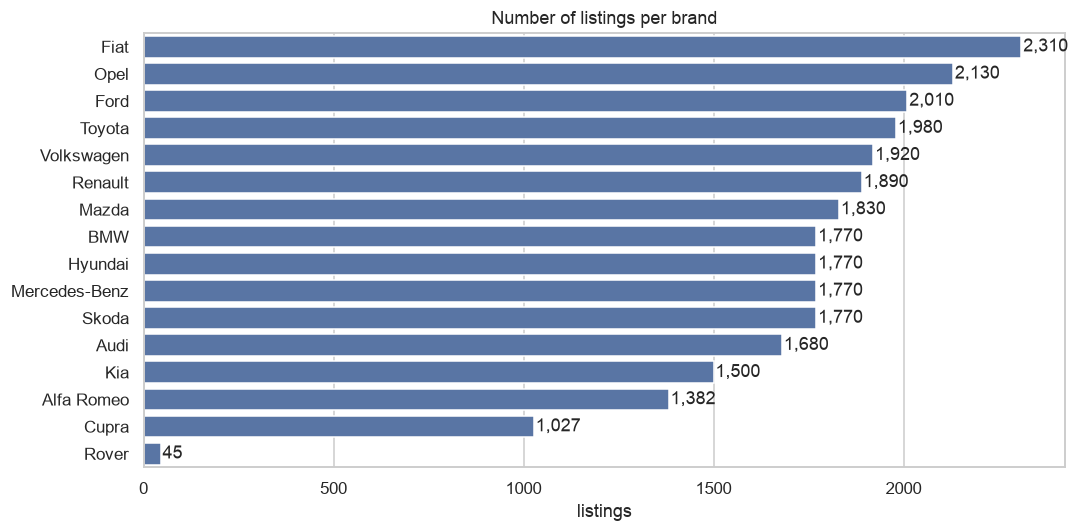

In [9]:
brand_counts = df["brand"].value_counts()

ax = sns.barplot(x=brand_counts.values, y=brand_counts.index, color="#4C72B0")
ax.set(title="Number of listings per brand", xlabel="listings", ylabel="")
for i, v in enumerate(brand_counts.values):
    ax.text(v + 5, i, f"{v:,}", va="center")
plt.tight_layout()
plt.show()

## 7. Price distribution

Prices are right-skewed (a few very expensive cars stretch the tail), so we look at
the distribution overall and a zoomed-in version up to the 99th percentile.

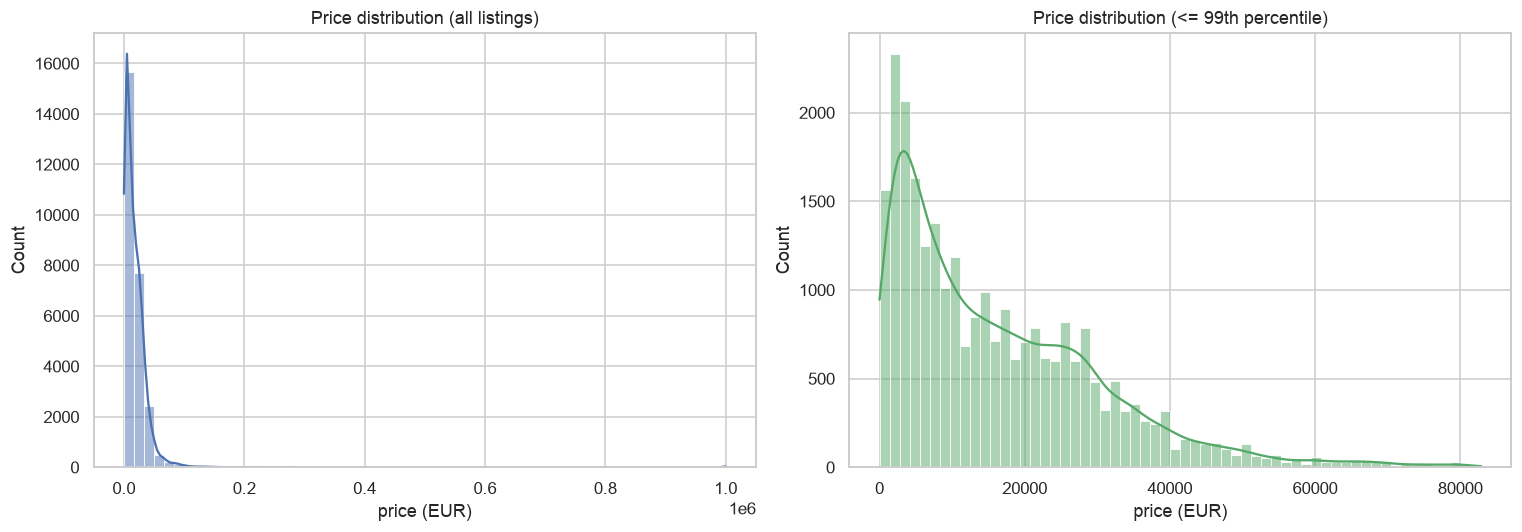

count     26784.0
mean      17931.0
std       31194.0
min           0.0
25%        4850.0
50%       12900.0
75%       24950.0
max      999999.0
Name: price_eur, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["price_eur"], bins=60, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set(title="Price distribution (all listings)", xlabel="price (EUR)")

cap = df["price_eur"].quantile(0.99)
sns.histplot(df.loc[df["price_eur"] <= cap, "price_eur"], bins=60, kde=True,
             ax=axes[1], color="#55A868")
axes[1].set(title="Price distribution (<= 99th percentile)", xlabel="price (EUR)")

plt.tight_layout()
plt.show()

print(df["price_eur"].describe().round(0))

## 8. Price by brand

Boxplots show the median, spread and outliers per brand at a glance.

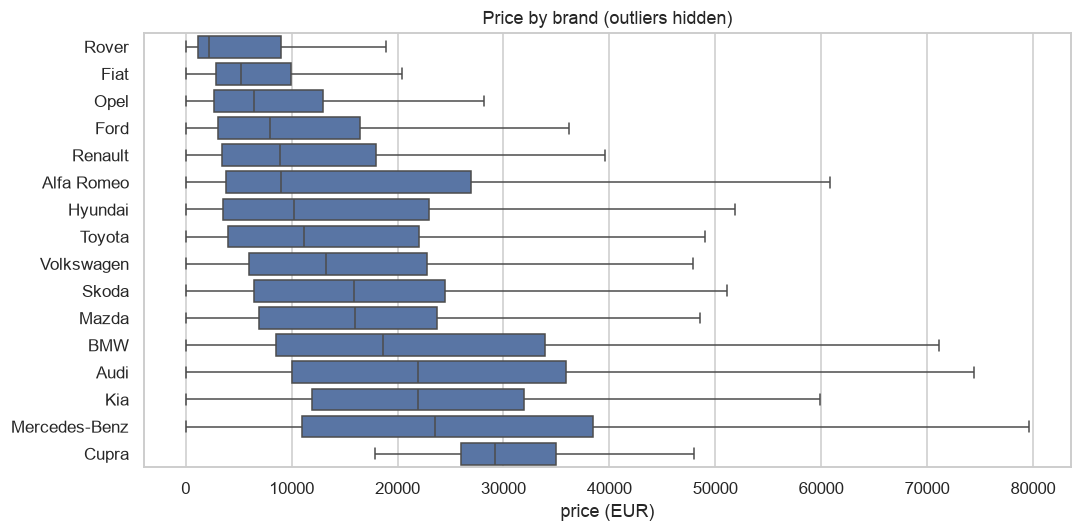

,count,median,mean,min,max
brand,,,,,
Alfa Romeo,1382,8955.0,16683.0,0.0,279000.0
Audi,1680,21922.0,27132.0,0.0,269950.0
BMW,1770,18618.0,26219.0,0.0,219950.0
Cupra,1027,29250.0,31102.0,0.0,64950.0
Fiat,2310,5250.0,8336.0,0.0,999999.0
Ford,2010,7950.0,13923.0,0.0,999999.0
Hyundai,1770,10242.0,15931.0,0.0,999999.0
Kia,1500,21950.0,22869.0,0.0,79000.0
Mazda,1830,15950.0,17383.0,0.0,999999.0


In [11]:
order = df.groupby("brand")["price_eur"].median().sort_values().index

ax = sns.boxplot(data=df, x="price_eur", y="brand", order=order, showfliers=False)
ax.set(title="Price by brand (outliers hidden)", xlabel="price (EUR)", ylabel="")
plt.tight_layout()
plt.show()

df.groupby("brand")["price_eur"].agg(["count", "median", "mean", "min", "max"]).round(0)

## 9. Mileage distribution

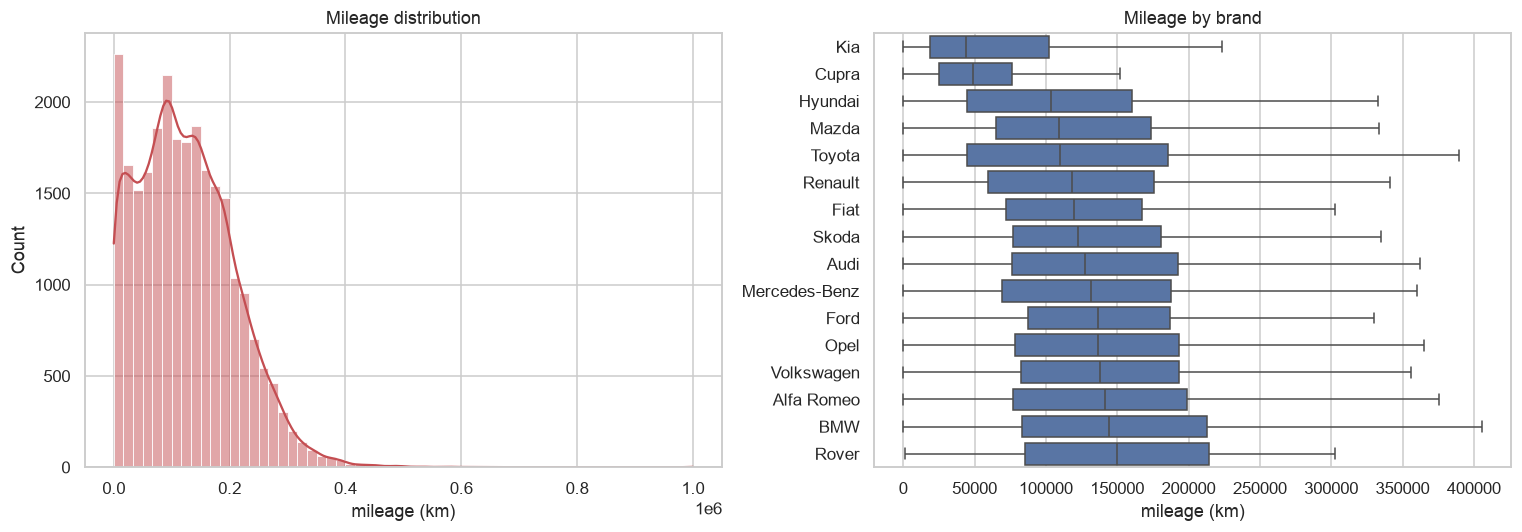

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["mileage_km"].dropna(), bins=60, kde=True, ax=axes[0], color="#C44E52")
axes[0].set(title="Mileage distribution", xlabel="mileage (km)")

sns.boxplot(data=df, x="mileage_km", y="brand",
            order=df.groupby("brand")["mileage_km"].median().sort_values().index,
            showfliers=False, ax=axes[1])
axes[1].set(title="Mileage by brand", xlabel="mileage (km)", ylabel="")

plt.tight_layout()
plt.show()

## 10. Build year & car age

When were these cars built, and how old are they?

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

year_counts = df["build_year"].value_counts().sort_index()
year_counts = year_counts[year_counts.index >= 2000]  # cut off: show build years 2000 and later
sns.barplot(x=year_counts.index.astype(int), y=year_counts.values, ax=axes[0], color="#8172B3")
axes[0].set(title="Listings per build year (2000+)", xlabel="build year", ylabel="listings")
axes[0].tick_params(axis="x", rotation=90)

sns.histplot(df["car_age"].dropna(), bins=int(df["car_age"].max() - df["car_age"].min() + 1),
             ax=axes[1], color="#937860")
axes[1].set(title="Car age distribution", xlabel=f"age in years (ref {REFERENCE_YEAR})")

plt.tight_layout()
plt.show()

## 11. Fuel type, transmission & body type

The categorical mix across the whole dataset.

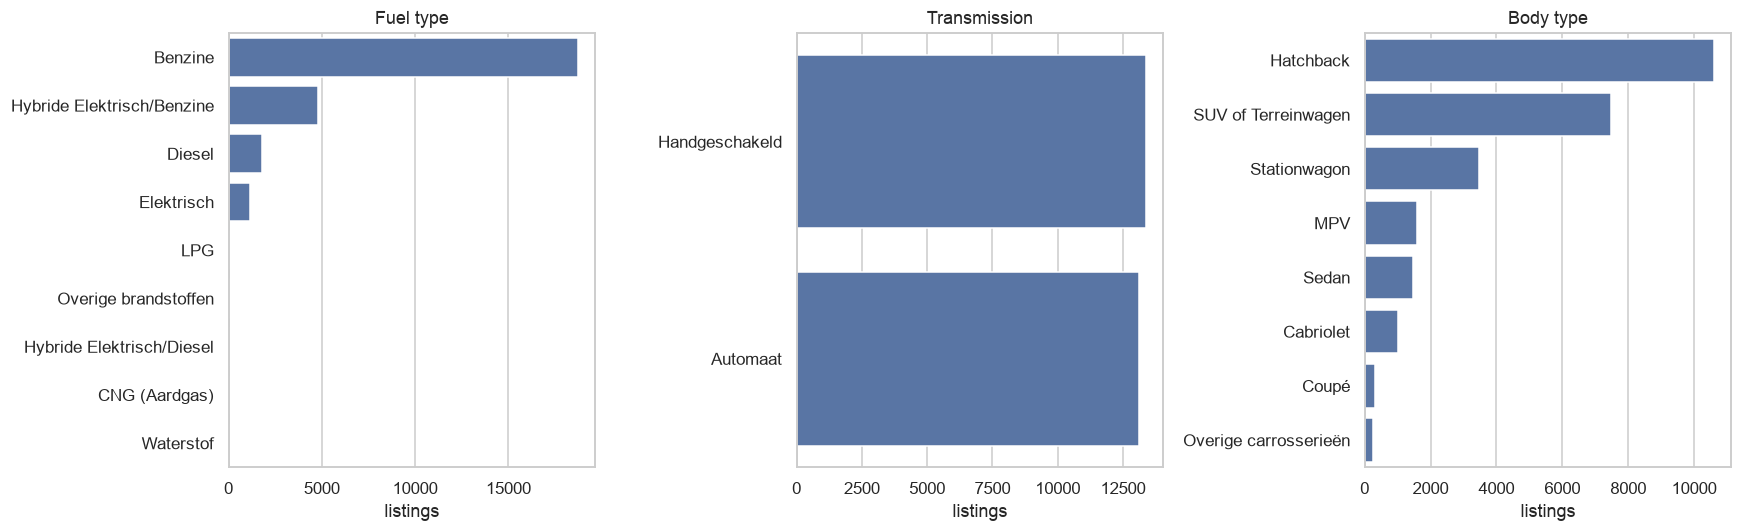

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(
    axes,
    ["fuel", "transmission", "body_type"],
    ["Fuel type", "Transmission", "Body type"],
):
    counts = df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=ax, color="#4C72B0")
    ax.set(title=title, xlabel="listings", ylabel="")

plt.tight_layout()
plt.show()

### Fuel mix per brand
Stacked composition — useful to see e.g. which brands lean hybrid or diesel.

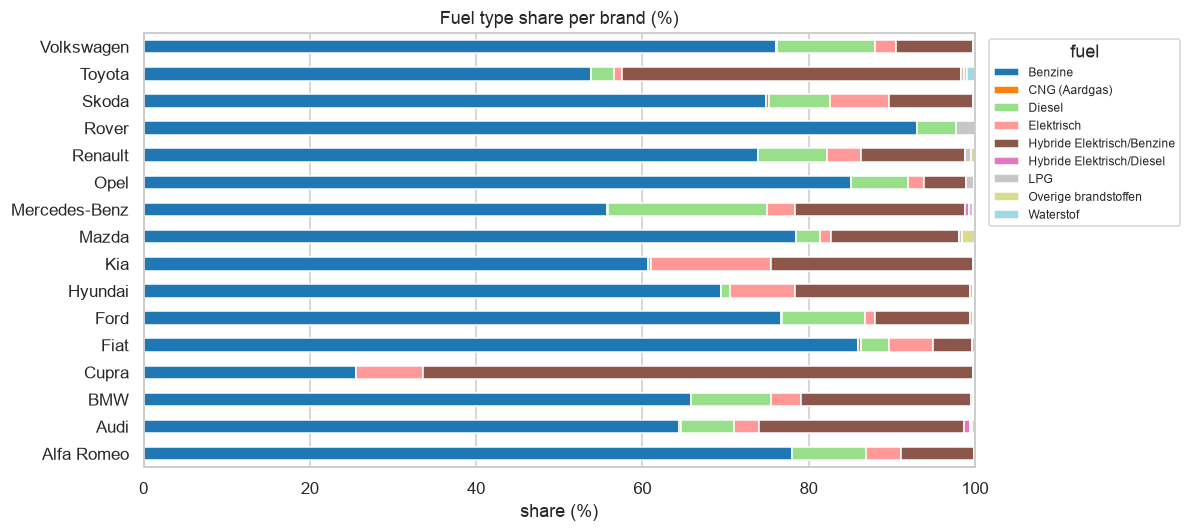

In [15]:
fuel_by_brand = (
    pd.crosstab(df["brand"], df["fuel"], normalize="index") * 100
)

ax = fuel_by_brand.plot(kind="barh", stacked=True, figsize=(11, 5), colormap="tab20")
ax.set(title="Fuel type share per brand (%)", xlabel="share (%)", ylabel="")
ax.legend(title="fuel", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 12. Most common models

Top 20 models by number of listings.

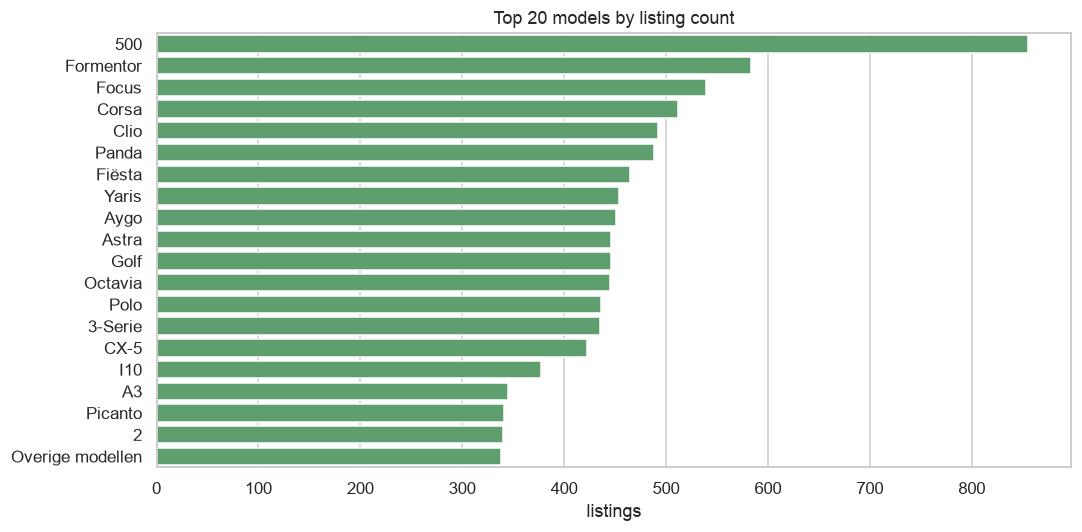

In [16]:
top_models = df["model"].value_counts().head(20)

ax = sns.barplot(x=top_models.values, y=top_models.index, color="#55A868")
ax.set(title="Top 20 models by listing count", xlabel="listings", ylabel="")
plt.tight_layout()
plt.show()

## 13. Relationships with price

How does price relate to mileage and to car age? We expect price to **fall** as
mileage and age rise.

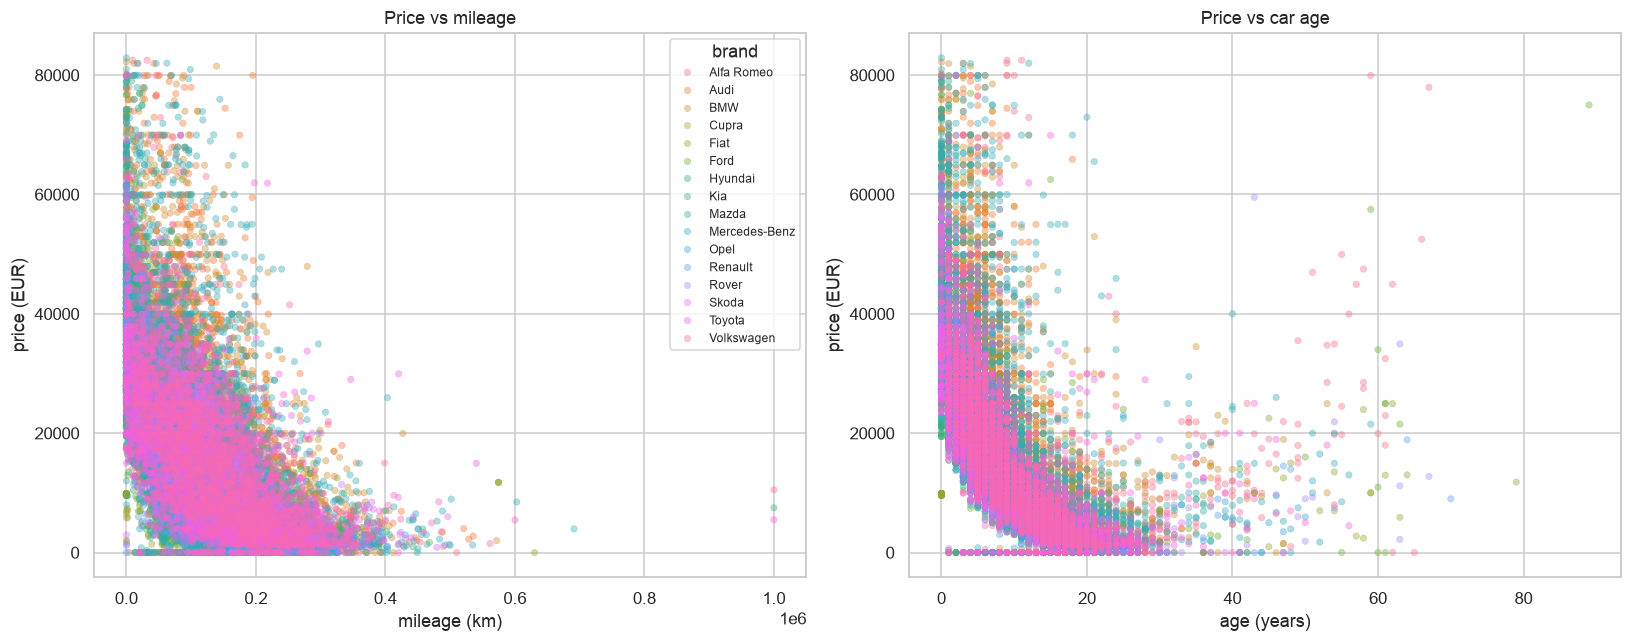

In [17]:
# Sample for a readable scatter, and cap price for a clearer view
plot_df = df[df["price_eur"] <= df["price_eur"].quantile(0.99)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=plot_df, x="mileage_km", y="price_eur", hue="brand",
                alpha=0.4, s=18, ax=axes[0], edgecolor=None)
axes[0].set(title="Price vs mileage", xlabel="mileage (km)", ylabel="price (EUR)")
axes[0].legend(fontsize=8, title="brand")

sns.scatterplot(data=plot_df, x="car_age", y="price_eur", hue="brand",
                alpha=0.4, s=18, ax=axes[1], edgecolor=None, legend=False)
axes[1].set(title="Price vs car age", xlabel="age (years)", ylabel="price (EUR)")

plt.tight_layout()
plt.show()

## 14. Correlation between numeric features

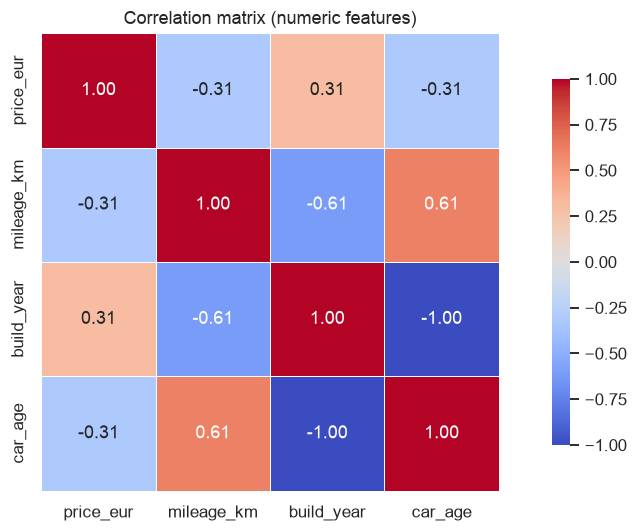

In [18]:
num_cols = ["price_eur", "mileage_km", "build_year", "car_age"]
corr = df[num_cols].corr()

ax = sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                 square=True, linewidths=.5, cbar_kws={"shrink": .8})
ax.set(title="Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

## 15. Summary table per brand

A compact reference table pulling the key numbers together.

In [19]:
summary = df.groupby("brand").agg(
    listings=("brand", "size"),
    median_price=("price_eur", "median"),
    mean_price=("price_eur", "mean"),
    median_mileage=("mileage_km", "median"),
    median_year=("build_year", "median"),
    pct_automatic=("transmission", lambda s: (s == "Automaat").mean() * 100),
).round(1).sort_values("median_price", ascending=False)

summary

,listings,median_price,mean_price,median_mileage,median_year,pct_automatic
brand,,,,,,
Cupra,1027,29250.0,31102.5,49195.0,2022.0,99.1
Mercedes-Benz,1770,23550.0,30417.1,131606.0,2018.0,83.7
Kia,1500,21950.0,22869.3,43851.0,2023.0,51.0
Audi,1680,21922.5,27132.3,127126.5,2018.0,79.8
BMW,1770,18617.5,26218.8,144370.0,2017.0,79.8
Mazda,1830,15950.0,17383.3,108878.0,2017.0,41.8
Skoda,1770,15890.0,16637.8,122488.0,2020.0,53.1
Volkswagen,1920,13249.5,15703.1,137912.0,2017.0,49.5
Toyota,1980,11200.0,14788.4,110020.0,2017.0,55.9


---

### Takeaways to explore next
- Price is strongly driven by **mileage**, **age** and **brand** — good candidate features for a price model.
- The premium brands (BMW, Mercedes-Benz) sit at higher median prices; Toyota/Mazda/VW cluster lower.
- Watch for **outliers** (very high prices, very high mileage) and any **missing** values before modelling.
